# Análisis explotario de datos y dashboard. Abandono de clientes en Telco

#### Hecho por Arturo Rosales V.

## Objetivo del proyecto
El objetivo es comprender el **por qué** los clientes abandonan la compañía telefónica Telco, y lograr predecir quiénes son los clientes que podrían irse. De esta manera, la compañía tendría la habilidad de actuar antes de perderlos. 

In [1]:
# A continuación, las librerías utilizadas en este proyecto son las siguientes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea

### 1. Comprensión del dataset


In [2]:
df = pd.read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**¿Qué es una fila?** 
Cada fila es un cliente único, distinguido por su customerID. Y en su correspondiente fila se expresa su comportamiento como Telco customer.

**¿Hay una columna Churn?** 
Así es. La última columna se llama **Churn** y tiene un valor de sí o no. Esto es importantísimo para el análisis porque entonces podemos comparar quiénes se fueron vs los que no se fueron. 

In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

El dataset está limpio. No cuenta con valores nulos por ningun sitio. De cualquier modo, esto será revisado más adelante con lujo de detalle.

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

El dataset muestra que 5174 de los customers (que representan un 73.4%) no se van de Telco, mientras que 1869 sí lo hacen (representando un 26.5%).

En total Telco cuenta entonces con 7043 clientes, cada fila con 21 columnas.
Hay un desbalance del 73% vs 27%. Aunque sí luce bastante manejable, no es extremo, podemos comprender el por qué sucede. 

### 2. Análisis por variable para inspección a detalle 

Analicemos con más detalle las variables *tenure*, *MonthlyCharges* y *Contract*, logrando comprender cómo se distribuyen los clientes.

#### Variable *tenure*

In [7]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Text(0.5, 1.0, 'Distribución de Tenure')

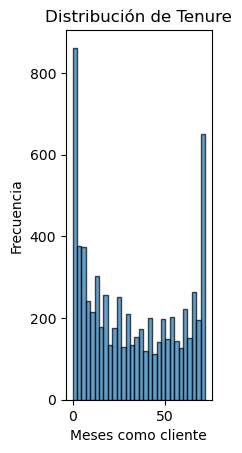

In [8]:
plt.subplot(1, 3, 1)
plt.hist(df['tenure'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Meses como cliente')
plt.ylabel('Frecuencia')
plt.title('Distribución de Tenure')

Hay dos picos muy evidentes en ésta distribución. Siendo así una distribución bimodal, hay muchos clientes nuevos con un rango de 0 a 10 meses, y muchos clientes antiguos con un rango de 60 a 72 meses, como vemos en su mínimo y máximo. Entonces, hay pocos clientes en el medio.

Los clientes o se van rápido o se quedan fieles a la compañía, luce como una zona de filtro de fidelidad en los primeros meses. 

#### Variable *Monthly charges*

In [9]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Text(0.5, 1.0, 'Distribución de cargos mensuales')

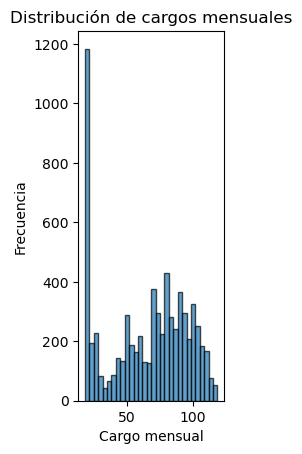

In [10]:
plt.subplot(1,3,2)
plt.hist(df['MonthlyCharges'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')
plt.title('Distribución de cargos mensuales')

La distribución de cargos mensuales es casi uniforme, con una pequeña concentración en extremos. Esto es, customers de $20 a $30, con servicios básicos, y clientes con paquetes más completos que van de $80 a $100. Pocos están en el medio, nuevamente. 

La compañía tiene dos segmentos: los customers con servicios básicos y customers con servicios completos.

#### Variable Contract 

In [11]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

(array([0, 1, 2]),
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'Two year'),
  Text(2, 0, 'One year')])

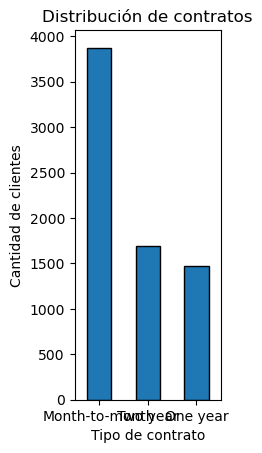

In [12]:
plt.subplot(1,3,3)
df['Contract'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de contratos')
plt.xticks(rotation=0)


Basado en los datos, los contratos Month-to-month (contratos mensuales) tienen un dominio evidente entre los tipos de contratos. Aproximadamente un 50% de los contratos activos son mensuales. 

Los contratos largos (esto es, de 1 a 2 años) suman 3168 customers (representando un 45% de los customers). Esto concluye con que más de la mitad de los clientes no tienen el compromiso a largo plazo con la compañía. Es un riesgo de churn. 

**¿Los clientes que se van tiene tenure bajo, cargos altos y contratos mensuales?**

### 3. Análisis de relaciones entre variables

**¿Qué es lo que caracteriza a los clientes que se van?**

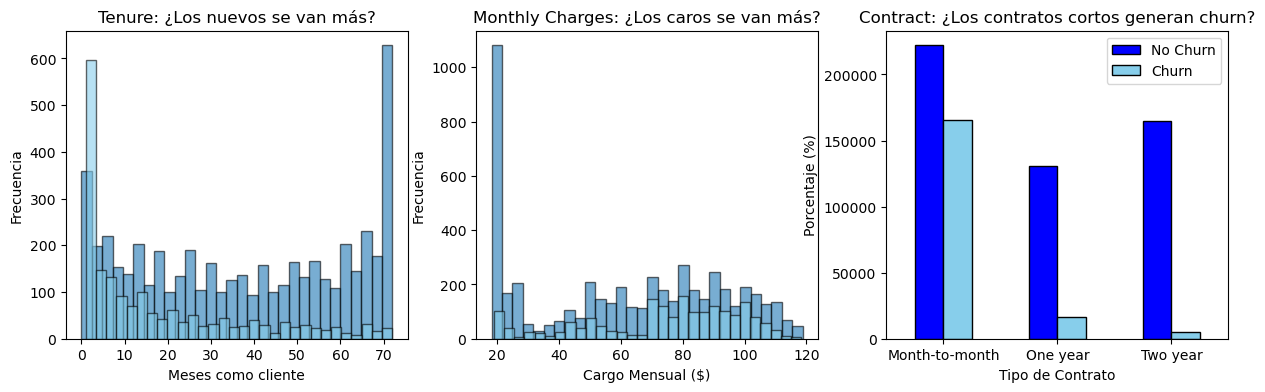

In [13]:
# Las gráficas cumplirán con el tamaño o configuración siguiente, para una visualización apropiada
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.6, label='No Churn', edgecolor='black')
axes[0].hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.6, label='Churn', edgecolor='black', color='skyblue')
axes[0].set_xlabel('Meses como cliente')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Tenure: ¿Los nuevos se van más?')

axes[1].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.6, label='No Churn', edgecolor='black')
axes[1].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.6, label='Churn', color='skyblue', edgecolor='black')
axes[1].set_xlabel('Cargo Mensual ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Monthly Charges: ¿Los caros se van más?')

churn_by_contract = pd.crosstab(df['Contract'], df['Churn']) * 100
churn_by_contract.plot(kind='bar', ax=axes[2], color=['blue', 'skyblue'], edgecolor='black')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].set_title('Contract: ¿Los contratos cortos generan churn?')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['No Churn', 'Churn'])

In [14]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [15]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [16]:
print(churn_by_contract)

Churn               No     Yes
Contract                      
Month-to-month  222000  165500
One year        130700   16600
Two year        164700    4800


Basado en los datos, los newer customers se van mucho más, así como los customers que pagan más. Los customers que hacen drop out tienen, en promedio, 18 meses de tenure en la compañía, y pagan en promedio $74 en promedio. 

El primer año es decisivo, si el customer se conserva por 24 meses, probablemente se queda.
¿Perciben menos valor por su dinero?  

Y cuando un customer es parte de la compañía con un contrato a largo plazo (como anual o bianual) se reduce el churn hasta un 15x, aproximadamente. El contrato a largo plazo es un asegurador de fidelidad de lo más fuerte, hasta ahora. 
Más de la mitad de los customers (un 55%) tienen contratos sin compromiso, representando el segmento de mayor riesgo de churn.

**¿Los clientes con contratos mensuales y cargos altos se van más?**

In [17]:
contratos_mensuales = df[df['Contract'] == 'Month-to-month']
contratos_anuales = df[df['Contract'] == 'One year']
contratos_bianuales = df[df['Contract'] == 'Two year']

In [18]:
mensuales_se_van = contratos_mensuales[contratos_mensuales['Churn'] == 'Yes']
mensuales_se_quedan = contratos_mensuales[contratos_mensuales['Churn'] == 'No']


In [19]:
print(mensuales_se_van['MonthlyCharges'].mean())
print(mensuales_se_quedan['MonthlyCharges'].mean())

73.01939577039275
61.46263513513513


In [20]:
print(mensuales_se_van['tenure'].mean())
print(mensuales_se_quedan['tenure'].mean())

14.016918429003022
21.033333333333335


(0.0, 40.0)

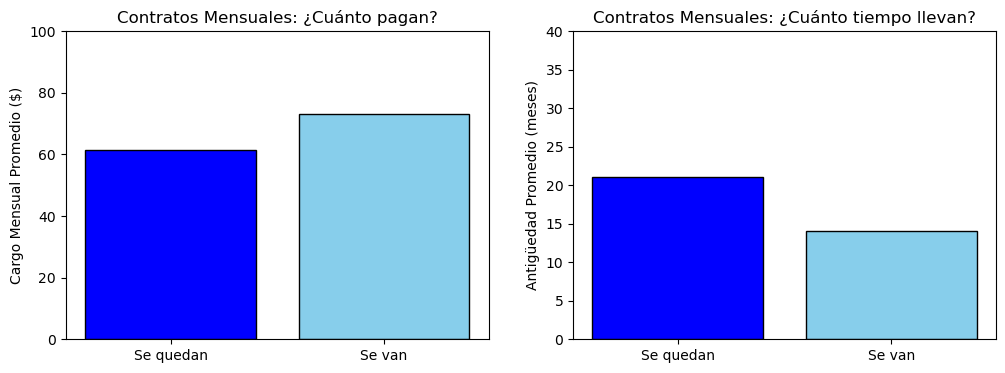

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Se quedan', 'Se van'], 
            [mensuales_se_quedan['MonthlyCharges'].mean(), 
             mensuales_se_van['MonthlyCharges'].mean()],
            color=['blue', 'skyblue'], edgecolor='black')
axes[0].set_ylabel('Cargo Mensual Promedio ($)')
axes[0].set_title('Contratos Mensuales: ¿Cuánto pagan?')
axes[0].set_ylim(0, 100)

axes[1].bar(['Se quedan', 'Se van'], 
            [mensuales_se_quedan['tenure'].mean(), 
             mensuales_se_van['tenure'].mean()],
            color=['blue', 'skyblue'], edgecolor='black')
axes[1].set_ylabel('Antigüedad Promedio (meses)')
axes[1].set_title('Contratos Mensuales: ¿Cuánto tiempo llevan?')
axes[1].set_ylim(0, 40)

Basado en los datos, es apropiado pensar en los customers con un contrato mensual caro y que tengan poco tiempo en la compañía. Menos de un año, digamos.

In [31]:
combo_peligroso = contratos_mensuales[
    (contratos_mensuales['MonthlyCharges'] > 70) & 
    (contratos_mensuales['tenure'] < 12)
]

total_combo = len(combo_peligroso)
se_van_combo = len(combo_peligroso[combo_peligroso['Churn'] == 'Yes'])
tasa_churn_combo = (se_van_combo / total_combo) * 100

print(f"Clientes con contrato mensual + cargo >$70 + antigüedad <12 meses: {total_combo}")
print(f"De ellos, se van: {se_van_combo}")
print(f"Tasa de churn: {tasa_churn_combo:.1f}%")

tasa_general = (len(df[df['Churn']=='Yes']) / len(df)) * 100
print(f"\nTasa general de churn: {tasa_general:.1f}%")
print(f"El combo peligroso tiene {tasa_churn_combo / tasa_general:.1f}x más churn")

Clientes con contrato mensual + cargo >$70 + antigüedad <12 meses: 814
De ellos, se van: 566
Tasa de churn: 69.5%

Tasa general de churn: 26.5%
El combo peligroso tiene 2.6x más churn


Hay un 69.5% de churn en customers con contrato Month-to-Month caro y poco tenure. Es el customer más susceptible a hacer drop out. 

Son 814 customers con éstas características, 566 de ellos ya se fueron, Telco podría actuar justo aquí. 

### 4. Conclusiones

- **El tipo de contrato es el indicador con más impacto en la variable Churn**
  Los contratos Month-to-month tiene 42.7% de churn, mientras que los contratos bianuales
  2.8%. Mi conclusión es que el compromiso a largo plazo de un customer reduce el Churn
  significativamente
- **Los primeros doce meses son decisivos para conservar un customer**
  Los clientes que hacen drop out se sitúan en un rango de 18 meses de antiguedad, y el análisis de relaciones revela una concentración de customers que hacen Churn y tienen menos de un año. 
- **Los cargos elevados correlacionan con una insatisfacción del customer**
  Customers que se van pagan en promedio 74.4 al mes, al lado de los customers que se
  conservan cuyo cargo es de 61.27. Esta diferencia de 13/mes apunta a un problema
  percepción. Los clientes no perciben un beneficio proporcional al tamaño de su
  inversión.
- **Existe un segmento de customers de gran riesgo a Churn**
  Los customers con contratos mensuales de cargos mayores a $70 y una antiguedad menor al
  año, presentan un 69.5% de churn. Siendo así, los 814 customers (11.5% del total) más
  susceptibles a Churn. De este segmento, 566 ya se fueron, evidenciando una fuga de
  ingresos para Telco.

Y este patrón de Churn no es aleatorio, me parece que incluso se puede predecir. Y estas conclusiones representan para Telco una oportunidad única de intervenir de manera proactiva.